# Proyecto 5: Modelo de difusión básico

**Estudiante:** Luis J. Baca Sandoval

**Cuaderno base:** `Cuaderno25-CC0C2.ipynb` 

**Tema central:** Evaluación del `trade-off` entre calidad de generación y tiempo de inferencia en modelos de difusión mediante la comparación de distintos métodos de muestreo.

---

### Autoría del código

Cada celda de código está etiquetada en su primera línea con una de estas marcas:

- `# [REUTILIZADO de Cuaderno25]` — código tomado tal cual del cuaderno base.
- `# [MODIFICADO de Cuaderno25]` — código del cuaderno base que adapté/corregí.
- `# [AGREGADO por el estudiante]` — código nuevo escrito por mí para este proyecto.
- `# [APOYO DE IA]` — código donde usé IA como apoyo.

Este notebook reconstruye una **línea base** de difusión (DDPM estocástico recorriendo todos los pasos),
introduce una **modificación significativa** (muestreo con número de pasos configurable y un **muestreador
DDIM determinista** implementado por el estudiante) y **compara cuantitativa y visualmente** ambas
configuraciones sobre MNIST, en **CPU** y de forma **reproducible**.


## 1. Objetivo

Demostrar, con evidencia interna y comparación cuantitativa, el **trade-off entre calidad y costo de
generación** en modelos de difusión, controlando dos perillas:

1. **El número de pasos de muestreo** (Ejercicio A, modificación común). Menos pasos → menor tiempo de
   inferencia, pero potencialmente peor calidad/coherencia.
2. **El tipo de muestreador**: DDPM estocástico vs **DDIM determinista** (Ejercicio B, modificación
   específica del Proyecto 5). DDIM permite saltar pasos y, con `eta=0`, hace el muestreo determinista
   (reproducible) a costa de diversidad.

El mismo `denoiser` entrenado una sola vez se usa para todas las configuraciones: **cambiamos solo el
muestreo**, nunca los pesos. Eso hace la comparación justa.


## 2. CELDA DE VERIFICACION PERSONAL

In [1]:
STUDENT_NAME = "Luis J. Baca Sandoval"
EXECUTION_DATE = "2026-06-23"
PROJECT_TRACK = "Proyecto 5: Modelo de difusión básico (DDPM/DDIM)"
MODEL_NAME = "TinyDenoiser propio (difusión sobre MNIST) + muestreadores DDPM y DDIM"
SEED = 42
DATASET = "MNIST (ylecun/mnist), imágenes 1x28x28 en escala de grises"
OBJETIVO = ("Entreno un único denoiser de difusión y comparo el muestreo DDPM completo (línea base) "
            "contra DDPM/DDIM con menos pasos, midiendo tiempo de generación y calidad de las muestras.")
VARIANT = "Muestreador DDIM determinista (eta=0) con submuestreo de pasos vs DDPM estocástico completo"

print("Estudiante:", STUDENT_NAME)
print("Fecha:", EXECUTION_DATE)
print("Línea de proyecto:", PROJECT_TRACK)
print("Modelo:", MODEL_NAME)
print("Semilla:", SEED)
print("Dataset:", DATASET)
print("Variante:", VARIANT)
print("Objetivo:", OBJETIVO)


Estudiante: Luis J. Baca Sandoval
Fecha: 2026-06-23
Línea de proyecto: Proyecto 5: Modelo de difusión básico (DDPM/DDIM)
Modelo: TinyDenoiser propio (difusión sobre MNIST) + muestreadores DDPM y DDIM
Semilla: 42
Dataset: MNIST (ylecun/mnist), imágenes 1x28x28 en escala de grises
Variante: Muestreador DDIM determinista (eta=0) con submuestreo de pasos vs DDPM estocástico completo
Objetivo: Entreno un único denoiser de difusión y comparo el muestreo DDPM completo (línea base) contra DDPM/DDIM con menos pasos, midiendo tiempo de generación y calidad de las muestras.


## 3. Marco teórico

### 3.1 Proceso *forward* (markoviano) y su forma cerrada

La difusión define un proceso que **destruye** la imagen agregando ruido gaussiano paso a paso. Es
**markoviano** porque $x_t$ depende solo de $x_{t-1}$:
$$q(x_t \mid x_{t-1}) = \mathcal{N}\big(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I\big).$$
Gracias a esa estructura existe una **forma cerrada** que salta directo de $x_0$ a $x_t$:
$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon,\qquad \epsilon\sim\mathcal{N}(0,I),$$
con $\alpha_t = 1-\beta_t$ y $\bar\alpha_t=\prod_{s\le t}\alpha_s$. En el código esto es exactamente la
función **`q_sample`**, y $\bar\alpha_t$ es el vector **`alpha_bars`**. Cuando $t\to T$, $\bar\alpha_t\to 0$
y $x_t$ se vuelve ruido casi puro.

### 3.2 Objetivo de entrenamiento: predecir el ruido

No predecimos la imagen limpia directamente: entrenamos una red $\epsilon_\theta(x_t, t)$ para estimar el
**ruido** $\epsilon$ que se inyectó, minimizando
$$\mathcal{L}=\mathbb{E}_{x_0,t,\epsilon}\,\lVert \epsilon - \epsilon_\theta(x_t,t)\rVert^2.$$
En el código es `train_denoiser` (pérdida `F.mse_loss(pred_noise, noise)`). Muestreamos `t` **al azar** para
que la red aprenda a quitar ruido en **todos** los niveles. La red recibe `t` mediante un *embedding*
temporal (`TimeEmbedding`), porque "quitar mucho ruido" y "quitar poco ruido" son tareas distintas.

### 3.3 Muestreo *reverse*

Para generar partimos de $x_T\sim\mathcal{N}(0,I)$ y deshacemos el ruido. De $\epsilon_\theta$ se despeja una
estimación de la imagen limpia:
$$\hat x_0 = \frac{1}{\sqrt{\bar\alpha_t}}\big(x_t-\sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t,t)\big).$$

- **DDPM** (línea base): reverse **estocástico**, reinyecta un poco de ruido en cada paso y recorre los
  `T` pasos. Es `sample_toy_ddpm`.
- **DDIM** (variante): usa $\hat x_0$ para construir directamente $x_{t-1}$ sobre una **subsecuencia** de
  tiempos $\tau_1>\dots>\tau_K$ con $K\ll T$. Un parámetro `eta` ($\eta$) controla cuánto ruido se
  reinyecta: `eta=0` ⇒ determinista (reproducible, rápido), `eta=1` ⇒ recupera el comportamiento
  estocástico tipo DDPM. Es `sample_ddim`.

**Idea unificadora del notebook:** un mismo muestreador respaciado `sample_ddim(..., num_steps, eta)`
cubre ambos casos; cambiar `num_steps` controla la **velocidad** y cambiar `eta` controla el
**determinismo/diversidad**.


## 4. Configuración e imports

In [2]:
# REUTILIZADO de Cuaderno25 (Semana12): imports base
import math, time, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


# REUTILIZADO de Cuaderno25 (Semana12): selección de dispositivo
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print("Dispositivo:", device)


# AÑADIDO por el estudiante: semilla global para reproducibilidad
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

# Hiperparámetros del experimento
T = 200                 # número total de pasos de difusión (define alpha_bars)
TRAIN_STEPS = 300       # pasos de entrenamiento del denoiser
N_SAMPLES = 16          # imágenes a generar por configuración
print("T =", T, "| TRAIN_STEPS =", TRAIN_STEPS, "| SEED =", SEED)


Dispositivo: cuda
T = 200 | TRAIN_STEPS = 300 | SEED = 42


In [3]:
# REUTILIZADO de Cuaderno25 (Semana12): utilidad de visualización en grilla
def show_images_grid(images, ncols=8, title=None, cmap="gray"):
    if isinstance(images, torch.Tensor):
        imgs = images.detach().cpu()
        if imgs.ndim == 2:
            imgs = imgs.unsqueeze(0).unsqueeze(0)
        elif imgs.ndim == 3:
            imgs = imgs.unsqueeze(1)
    else:
        proc = []
        for im in images:
            arr = np.array(im) if isinstance(im, Image.Image) else np.array(im)
            if arr.ndim == 2:
                arr = arr[None, ...]
            elif arr.ndim == 3 and arr.shape[-1] in (1, 3):
                arr = np.transpose(arr, (2, 0, 1))
            proc.append(torch.tensor(arr))
        imgs = torch.stack(proc)

    imgs = imgs.float()
    if imgs.max() > 1.5:
        imgs = imgs / 255.0

    n = len(imgs)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.6*ncols, 1.6*nrows))
    axes = np.array(axes).reshape(-1)
    for ax in axes: ax.axis("off")
    for i in range(n):
        img = imgs[i]
        if img.shape[0] == 1:
            axes[i].imshow(img[0], cmap=cmap)
        else:
            axes[i].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


## 5. Dataset: MNIST

Usamos MNIST (dígitos 0-9, imágenes 1×28×28 en `[0,1]`).

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

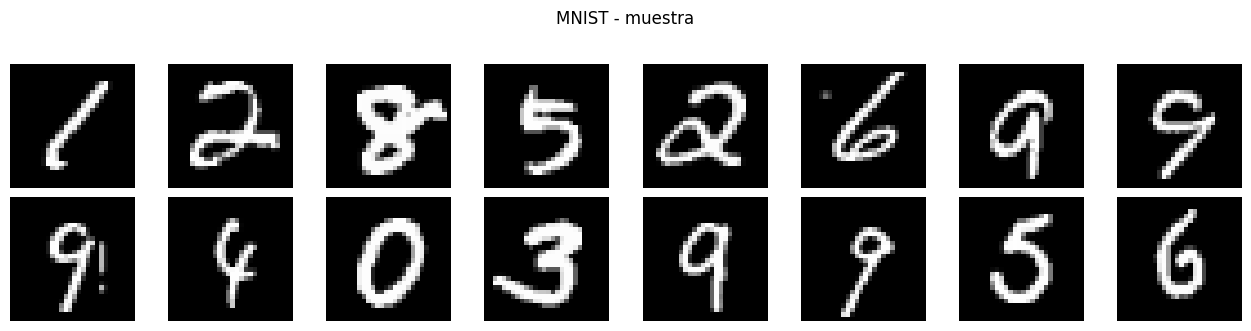

Forma del batch de imágenes (x0): torch.Size([128, 1, 28, 28])


In [4]:
# REUTILIZADO de Cuaderno25 (Semana12): carga de MNIST y DataLoaders
from datasets import load_dataset
from torchvision import transforms

mnist = load_dataset("ylecun/mnist")
to_tensor = transforms.ToTensor()

def transform_batch(examples):
    examples["image"] = [to_tensor(img) for img in examples["image"]]
    return examples

mnist = mnist.with_transform(transform_batch)

train_loader = DataLoader(mnist["train"], batch_size=128, shuffle=True)
test_loader  = DataLoader(mnist["test"],  batch_size=128, shuffle=False)

batch = next(iter(train_loader))
show_images_grid(batch["image"][:16], ncols=8, title="MNIST - muestra")
print("Forma del batch de imágenes (x0):", batch["image"].shape)  # [B, 1, 28, 28]


## 6. Proceso *forward*: agregar ruido (`q_sample`)

Visualizamos la forma cerrada $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$ a distintos `t`.
A mayor `t`, menor $\bar\alpha_t$ y más ruido: el dígito deja de ser reconocible.

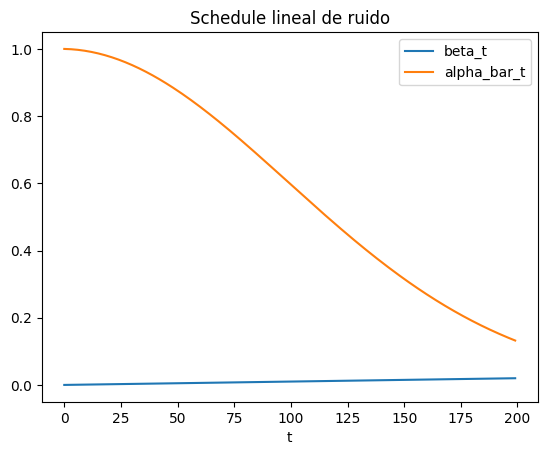

alpha_bar_0 = 0.9999  (poco ruido)   alpha_bar_{T-1} = 0.1322  (casi ruido puro)


In [5]:
# REUTILIZADO de Cuaderno25 (Semana12): schedule lineal y cantidades derivadas
def linear_beta_schedule(T=200, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

betas = linear_beta_schedule(T)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)   # \bar{alpha}_t

plt.plot(betas.numpy(), label="beta_t")
plt.plot(alpha_bars.numpy(), label="alpha_bar_t")
plt.title("Schedule lineal de ruido"); plt.xlabel("t"); plt.legend(); plt.show()
print("alpha_bar_0 = %.4f  (poco ruido)   alpha_bar_{T-1} = %.4f  (casi ruido puro)"
      % (alpha_bars[0].item(), alpha_bars[-1].item()))


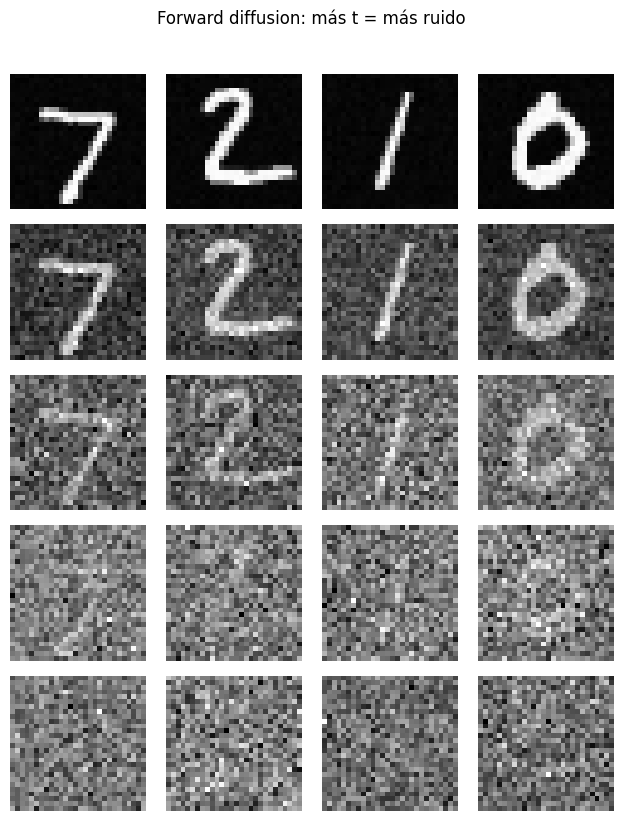

Tiempos mostrados (de izq. a der.): [0, 20, 60, 120, 199]


In [6]:
# REUTILIZADO de Cuaderno25 (Semana12): proceso forward en forma cerrada
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    if isinstance(t, int):
        t = torch.tensor([t], device=x0.device).repeat(x0.shape[0])
    a_bar_t = alpha_bars.to(x0.device)[t].view(-1, 1, 1, 1)
    x_t = torch.sqrt(a_bar_t) * x0 + torch.sqrt(1 - a_bar_t) * noise
    return x_t, noise


# REUTILIZADO de Cuaderno25 (Semana12): visualización del forward diffusion
xb = next(iter(test_loader))["image"][:4].to(device)
times = [0, 20, 60, 120, 199]
viz = []
for t in times:
    x_t, _ = q_sample(xb, t)
    viz.extend([im for im in x_t.cpu()])
show_images_grid(viz, ncols=4, title="Forward diffusion: más t = más ruido")
print("Tiempos mostrados (de izq. a der.):", times)


## 7. Denoiser y entrenamiento

`TinyDenoiser` predice el ruido $\epsilon_\theta(x_t,t)$. El tiempo `t` entra por un *embedding* y modula
las activaciones (estilo FiLM: `h*(1+scale)+shift`). Entrenamos minimizando el MSE entre el ruido real y
el predicho.

In [7]:
# REUTILIZADO de Cuaderno25 (Semana12): embedding temporal + denoiser mínimo
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, dim), nn.ReLU(), nn.Linear(dim, dim))
    def forward(self, t):
        return self.net((t.float() / T).unsqueeze(-1))

class TinyDenoiser(nn.Module):
    def __init__(self, time_dim=32):
        super().__init__()
        self.time_mlp = TimeEmbedding(time_dim)
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 1, 3, padding=1)
        self.to_scale = nn.Linear(time_dim, 32)
        self.to_shift = nn.Linear(time_dim, 32)
    def forward(self, x, t):
        temb = self.time_mlp(t)
        scale = self.to_scale(temb).unsqueeze(-1).unsqueeze(-1)
        shift = self.to_shift(temb).unsqueeze(-1).unsqueeze(-1)
        h = self.conv1(x)
        h = F.relu(h * (1 + scale) + shift)
        h = F.relu(self.conv2(h))
        return self.conv3(h)


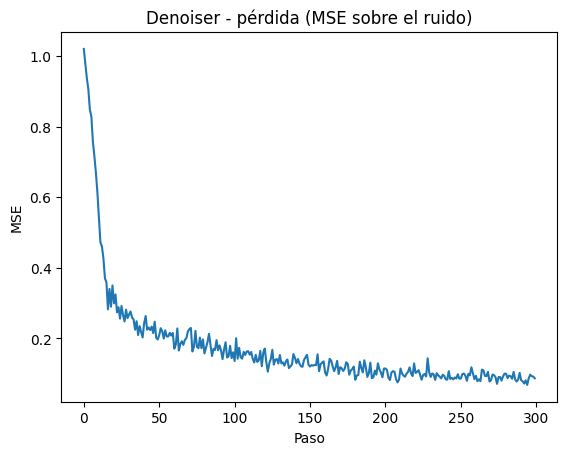

Parámetros del denoiser: 13089
Última pérdida: 0.0870683491230011


In [8]:
# REUTILIZADO de Cuaderno25 (Semana12): bucle de entrenamiento del denoiser
def train_denoiser(model, loader, optimizer, steps=300):
    model.train()
    losses = []
    step = 0
    while step < steps:
        for batch in loader:
            x0 = batch["image"].to(device)
            bsz = x0.size(0)
            t = torch.randint(0, T, (bsz,), device=device)   # t aleatorio: aprende todos los niveles
            x_t, noise = q_sample(x0, t)
            pred_noise = model(x_t, t)
            loss = F.mse_loss(pred_noise, noise)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            losses.append(loss.item()); step += 1
            if step >= steps:
                break
    return losses

set_seed(SEED)
denoiser = TinyDenoiser().to(device)
opt_diff = torch.optim.Adam(denoiser.parameters(), lr=1e-3)

diff_losses = train_denoiser(denoiser, train_loader, opt_diff, steps=TRAIN_STEPS)
plt.plot(diff_losses); plt.title("Denoiser - pérdida (MSE sobre el ruido)")
plt.xlabel("Paso"); plt.ylabel("MSE"); plt.show()
print("Parámetros del denoiser:", sum(p.numel() for p in denoiser.parameters()))
print("Última pérdida:", diff_losses[-1])


## 8. Línea base: DDPM estocástico completo (`T` pasos)

`sample_toy_ddpm` recorre los `T=200` pasos con reinyección de ruido. Es la referencia contra la que
compararemos todas las variantes.

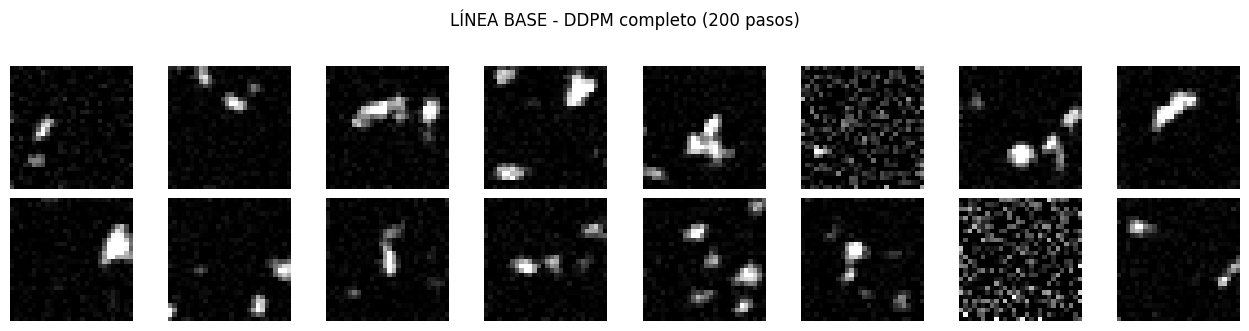

Tiempo de generación (línea base, 200 pasos): 0.377 s


In [9]:
# REUTILIZADO de Cuaderno25 (Semana12): muestreo DDPM didáctico (T pasos, estocástico)
@torch.no_grad()
def sample_toy_ddpm(model, n_samples=16):
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28, device=device)
    for t_inv in range(T - 1, -1, -1):
        t = torch.full((n_samples,), t_inv, device=device, dtype=torch.long)
        pred_noise = model(x, t)
        a_t = alphas.to(device)[t].view(-1, 1, 1, 1)
        a_bar_t = alpha_bars.to(device)[t].view(-1, 1, 1, 1)
        beta_t = betas.to(device)[t].view(-1, 1, 1, 1)
        x = (1 / torch.sqrt(a_t)) * (x - ((1 - a_t) / torch.sqrt(1 - a_bar_t)) * pred_noise)
        if t_inv > 0:
            x = x + torch.sqrt(beta_t) * torch.randn_like(x)
    return x.clamp(0, 1)

set_seed(SEED)
t0 = time.perf_counter()
samples_base = sample_toy_ddpm(denoiser, n_samples=N_SAMPLES)
tiempo_base = time.perf_counter() - t0
show_images_grid(samples_base.cpu(), ncols=8, title="LÍNEA BASE - DDPM completo (%d pasos)" % T)
print("Tiempo de generación (línea base, %d pasos): %.3f s" % (T, tiempo_base))


## 9. Tabla de dimensiones y evidencia de cálculo interno

Imprimimos: imagen original, imagen ruidosa en
`t`, ruido agregado, ruido predicho por la red, imagen tras un paso de *denoising* y número de pasos.

In [10]:
# AÑADIDO por el estudiante: evidencia interna (shapes) de un paso de difusión y un paso reverse
xb = next(iter(test_loader))["image"][:8].to(device)
t_demo = torch.full((xb.size(0),), 100, device=device, dtype=torch.long)

xt, noise = q_sample(xb, t_demo)                 # forward
predicted_noise = denoiser(xt, t_demo)           # ruido estimado

# un paso reverse DDPM (de t=100 a t=99) reutilizando la fórmula de la línea base
a_t = alphas.to(device)[t_demo].view(-1, 1, 1, 1)
a_bar_t = alpha_bars.to(device)[t_demo].view(-1, 1, 1, 1)
x_t_minus_1 = (1 / torch.sqrt(a_t)) * (xt - ((1 - a_t) / torch.sqrt(1 - a_bar_t)) * predicted_noise)

print("Imagen original (x0):     ", tuple(xb.shape))
print("Imagen en paso t (xt):    ", tuple(xt.shape))
print("Ruido agregado (noise):   ", tuple(noise.shape))
print("Predicción de ruido:      ", tuple(predicted_noise.shape))
print("Imagen denoised (x_{t-1}):", tuple(x_t_minus_1.shape))
print("Número de pasos (T):      ", T)
print()
print("Tabla de dimensiones")
print("%-26s %-18s %s" % ("Tensor", "Forma", "Significado"))
for nombre, tns, sig in [
    ("x0 (imagen original)",    xb,              "imagen limpia en [0,1]"),
    ("xt (imagen ruidosa)",     xt,              "x0 corrompida a t=100"),
    ("noise (ruido real)",      noise,           "epsilon ~ N(0, I)"),
    ("pred_noise (epsilon_θ)",  predicted_noise, "ruido estimado por el denoiser"),
    ("alpha_bars",              alpha_bars,      "producto acumulado de alphas (T,)"),
]:
    print("%-26s %-18s %s" % (nombre, str(tuple(tns.shape)), sig))


Imagen original (x0):      (8, 1, 28, 28)
Imagen en paso t (xt):     (8, 1, 28, 28)
Ruido agregado (noise):    (8, 1, 28, 28)
Predicción de ruido:       (8, 1, 28, 28)
Imagen denoised (x_{t-1}): (8, 1, 28, 28)
Número de pasos (T):       200

Tabla de dimensiones
Tensor                     Forma              Significado
x0 (imagen original)       (8, 1, 28, 28)     imagen limpia en [0,1]
xt (imagen ruidosa)        (8, 1, 28, 28)     x0 corrompida a t=100
noise (ruido real)         (8, 1, 28, 28)     epsilon ~ N(0, I)
pred_noise (epsilon_θ)     (8, 1, 28, 28)     ruido estimado por el denoiser
alpha_bars                 (200,)             producto acumulado de alphas (T,)


## 10. Ejercicio A — Modificación común obligatoria: número de pasos de muestreo

Primero implementamos un **muestreador respaciado** que sirve para todo el resto del notebook: recorre una
**subsecuencia** de `num_steps` tiempos (en vez de los `T`) y usa el parámetro `eta` para controlar el
ruido. Con `eta=1.0` se comporta como DDPM estocástico; con `eta=0.0` es DDIM determinista.

**Variable que cambio:** `num_steps ∈ {200, 100, 50, 20}`.
**Variables que mantengo constantes:** el denoiser entrenado, el schedule, la semilla y `eta=1.0`.

In [11]:
# AÑADIDO por el estudiante: muestreador DDIM respaciado y general.
@torch.no_grad()
def sample_ddim(model, n_samples=16, num_steps=50, eta=0.0, seed=None):
    """Muestreo con subsecuencia de tiempos.
    eta=0 -> DDIM determinista (reproducible); eta=1 -> estocástico tipo DDPM."""
    model.eval()
    if seed is not None:
        set_seed(seed)
    ab = alpha_bars.to(device)
    # subsecuencia creciente de tiempos en {0,...,T-1}; la recorremos de mayor a menor
    seq = torch.linspace(0, T - 1, num_steps).round().long().to(device)
    x = torch.randn(n_samples, 1, 28, 28, device=device)
    for i in reversed(range(num_steps)):
        t = int(seq[i])
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        ab_t = ab[t].view(1, 1, 1, 1)
        ab_prev = ab[int(seq[i - 1])].view(1, 1, 1, 1) if i > 0 else torch.ones(1, 1, 1, 1, device=device)

        eps = model(x, t_batch)
        x0_hat = ((x - torch.sqrt(1 - ab_t) * eps) / torch.sqrt(ab_t)).clamp(0, 1)

        sigma = eta * torch.sqrt((1 - ab_prev) / (1 - ab_t)) * torch.sqrt((1 - ab_t / ab_prev).clamp(min=0))
        dir_xt = torch.sqrt((1 - ab_prev - sigma ** 2).clamp(min=0)) * eps
        z = torch.randn_like(x) if (eta > 0 and i > 0) else torch.zeros_like(x)
        x = torch.sqrt(ab_prev) * x0_hat + dir_xt + sigma * z
    return x.clamp(0, 1)


# AÑADIDO por el estudiante: medidor de tiempo de generación (wall-clock)
def measure_generation(sampler_fn, **kwargs):
    set_seed(SEED)
    t0 = time.perf_counter()
    out = sampler_fn(**kwargs)
    dt = time.perf_counter() - t0
    return out, dt


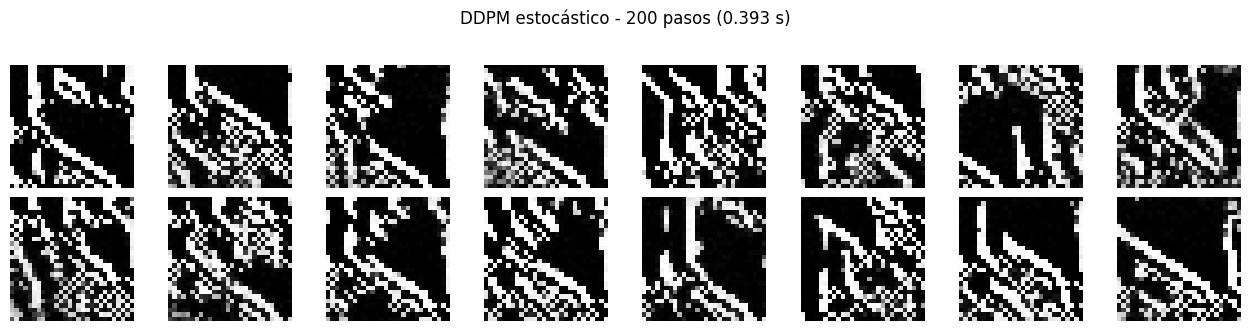

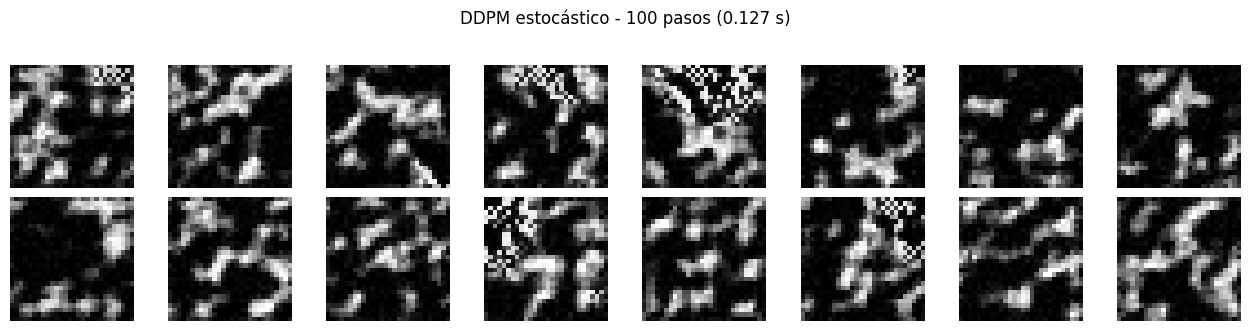

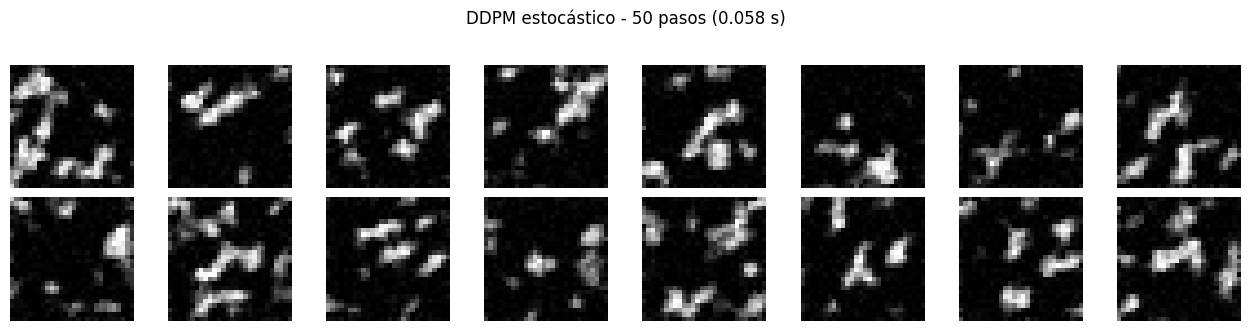

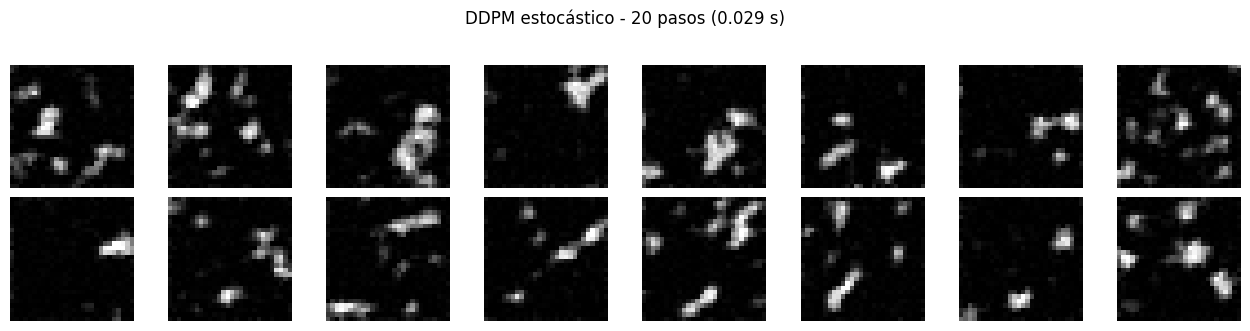

Tiempo de generación por número de pasos (DDPM, eta=1.0):
  200 pasos -> 0.393 s
  100 pasos -> 0.127 s
   50 pasos -> 0.058 s
   20 pasos -> 0.029 s


In [12]:
# AÑADIDO por el estudiante: barrido del número de pasos (DDPM estocástico, eta=1.0)
pasos_grid = [200, 100, 50, 20]
res_A = {}
for ns in pasos_grid:
    imgs, dt = measure_generation(sample_ddim, model=denoiser, n_samples=N_SAMPLES,
                                  num_steps=ns, eta=1.0)
    res_A[ns] = (imgs, dt)
    show_images_grid(imgs.cpu(), ncols=8, title="DDPM estocástico - %d pasos (%.3f s)" % (ns, dt))

print("Tiempo de generación por número de pasos (DDPM, eta=1.0):")
for ns in pasos_grid:
    print("  %3d pasos -> %.3f s" % (ns, res_A[ns][1]))


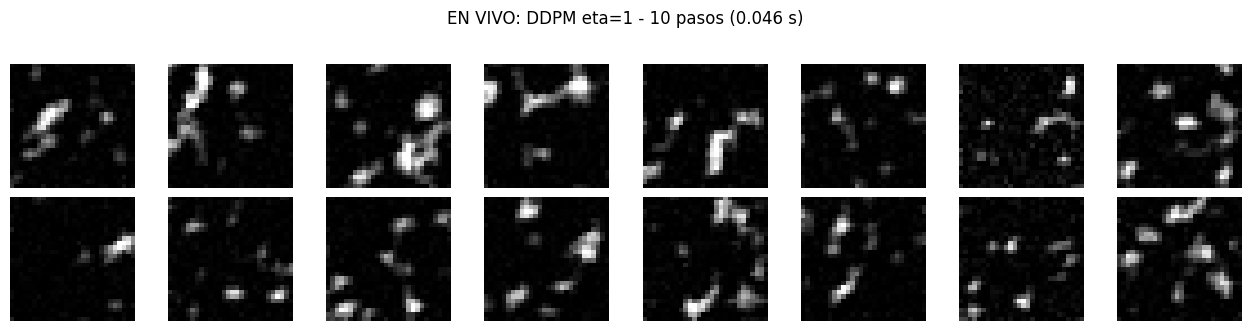

10 pasos -> tiempo: 0.046 s | nitidez: 0.0972 | confianza: 0.568 | entropía: 1.191


In [25]:
imgs_10, dt_10 = measure_generation(sample_ddim, model=denoiser, n_samples=N_SAMPLES,
                                    num_steps=10, eta=1.0)
show_images_grid(imgs_10.cpu(), ncols=8, title="EN VIVO: DDPM eta=1 - 10 pasos (%.3f s)" % dt_10)
conf, ent = semantic_scores(clf, imgs_10)
print("10 pasos -> tiempo: %.3f s | nitidez: %.4f | confianza: %.3f | entropía: %.3f"
      % (dt_10, sharpness(imgs_10), conf, ent))

## 11. Ejercicio B — Modificación específica del Proyecto 5: muestreador DDIM determinista

**Modificación:** comparar, **al mismo número de pasos**, el muestreo **DDPM estocástico** (`eta=1.0`)
contra **DDIM determinista** (`eta=0.0`).

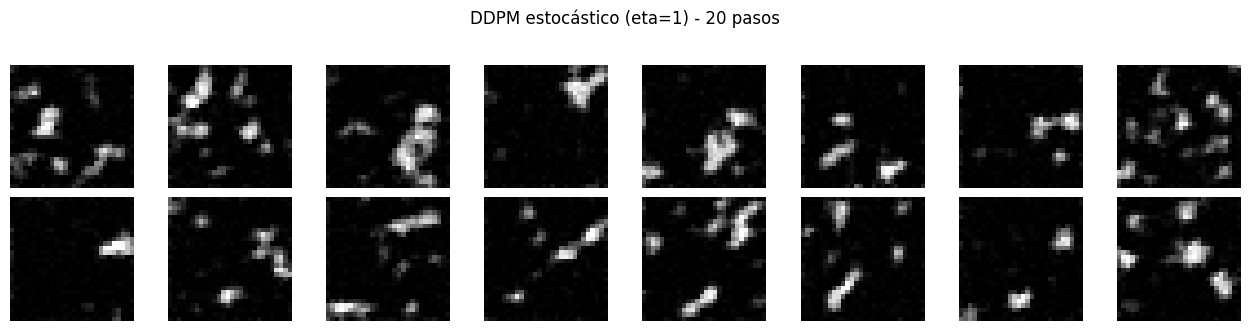

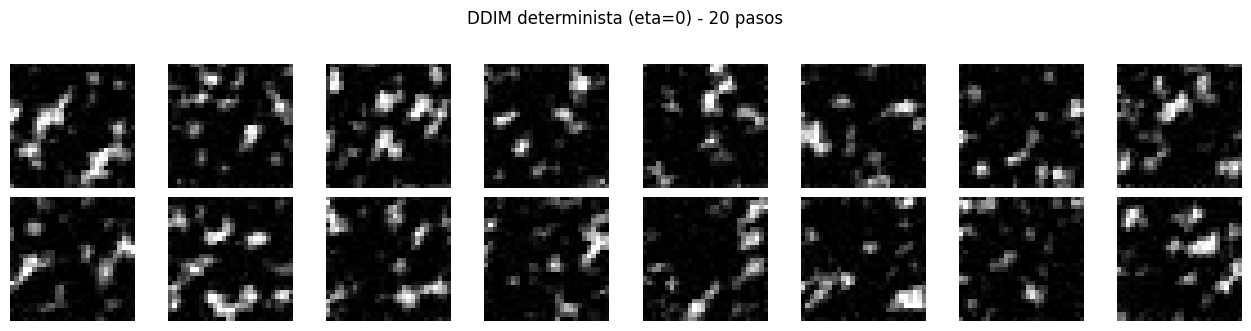

Tiempo DDPM (eta=1): 0.094 s | Tiempo DDIM (eta=0): 0.040 s


In [13]:
# AÑADIDO por el estudiante: DDPM (eta=1) vs DDIM (eta=0) al mismo número de pasos
NUM_STEPS_B = 20

imgs_ddpm, dt_ddpm = measure_generation(sample_ddim, model=denoiser, n_samples=N_SAMPLES,
                                        num_steps=NUM_STEPS_B, eta=1.0)
imgs_ddim, dt_ddim = measure_generation(sample_ddim, model=denoiser, n_samples=N_SAMPLES,
                                        num_steps=NUM_STEPS_B, eta=0.0)

show_images_grid(imgs_ddpm.cpu(), ncols=8, title="DDPM estocástico (eta=1) - %d pasos" % NUM_STEPS_B)
show_images_grid(imgs_ddim.cpu(), ncols=8, title="DDIM determinista (eta=0) - %d pasos" % NUM_STEPS_B)
print("Tiempo DDPM (eta=1): %.3f s | Tiempo DDIM (eta=0): %.3f s" % (dt_ddpm, dt_ddim))


In [14]:
# AÑADIDO por el estudiante: prueba de reproducibilidad (determinismo de DDIM)
a = sample_ddim(denoiser, n_samples=N_SAMPLES, num_steps=NUM_STEPS_B, eta=0.0, seed=SEED)
b = sample_ddim(denoiser, n_samples=N_SAMPLES, num_steps=NUM_STEPS_B, eta=0.0, seed=SEED)
dif_ddim = (a - b).abs().max().item()

c = sample_ddim(denoiser, n_samples=N_SAMPLES, num_steps=NUM_STEPS_B, eta=1.0, seed=SEED)
d = sample_ddim(denoiser, n_samples=N_SAMPLES, num_steps=NUM_STEPS_B, eta=1.0, seed=SEED)
dif_ddpm = (c - d).abs().max().item()

print("Diferencia máx. entre 2 corridas con misma semilla:")
print("  DDIM (eta=0): %.2e  -> %s" % (dif_ddim, "idénticas (determinista)" if dif_ddim < 1e-5 else "difieren"))
print("  DDPM (eta=1): %.2e  -> %s" % (dif_ddpm, "idénticas" if dif_ddpm < 1e-5 else "difieren (estocástico intra-cadena)"))


Diferencia máx. entre 2 corridas con misma semilla:
  DDIM (eta=0): 0.00e+00  -> idénticas (determinista)
  DDPM (eta=1): 0.00e+00  -> idénticas


## 12. Comparación cuantitativa: línea base vs variantes

Usamos dos proxies objetivos:

- **Nitidez** = magnitud media de gradiente espacial (más alto ≈ bordes más definidos).
- **Clasificador MNIST diminuto** entrenado ~1 pasada: reportamos la **confianza media** (probabilidad
  máxima) y la **entropía media** de las predicciones sobre las muestras generadas. Más confianza y menos
  entropía ≈ las muestras "parecen dígitos" reconocibles.

In [15]:
# AÑADIDO por el estudiante: clasificador MNIST diminuto como evaluador semántico
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32 * 7 * 7, 10),
        )
    def forward(self, x):
        return self.net(x)

def train_classifier(model, loader, steps=400):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train(); step = 0
    while step < steps:
        for batch in loader:
            x = batch["image"].to(device); y = batch["label"].to(device)
            loss = F.cross_entropy(model(x), y)
            opt.zero_grad(); loss.backward(); opt.step()
            step += 1
            if step >= steps:
                break
    return model

set_seed(SEED)
clf = train_classifier(SmallCNN().to(device), train_loader, steps=400)

@torch.no_grad()
def sharpness(imgs):
    gx = (imgs[:, :, :, 1:] - imgs[:, :, :, :-1]).abs().mean()
    gy = (imgs[:, :, 1:, :] - imgs[:, :, :-1, :]).abs().mean()
    return (gx + gy).item()

@torch.no_grad()
def semantic_scores(clf, imgs):
    probs = F.softmax(clf(imgs.to(device)), dim=1)
    conf = probs.max(dim=1).values.mean().item()
    ent = (-(probs * torch.log(probs + 1e-9)).sum(dim=1)).mean().item()
    return conf, ent

# sanity-check: confianza del clasificador sobre imágenes reales
real = next(iter(test_loader))["image"][:N_SAMPLES].to(device)
print("Referencia (imágenes reales): nitidez=%.4f, confianza=%.3f, entropía=%.3f"
      % ((sharpness(real),) + semantic_scores(clf, real)))


Referencia (imágenes reales): nitidez=0.1307, confianza=0.941, entropía=0.136


In [16]:
# AÑADIDO por el estudiante: tabla comparativa base vs variantes
def fila(nombre, imgs, dt):
    conf, ent = semantic_scores(clf, imgs)
    return {"config": nombre, "pasos": None, "tiempo_s": round(dt, 3),
            "nitidez": round(sharpness(imgs), 4), "confianza": round(conf, 3),
            "entropia": round(ent, 3)}

filas = []
# Línea base (DDPM completo, T pasos)
r = fila("BASE DDPM completo", samples_base, tiempo_base); r["pasos"] = T; filas.append(r)
# Variantes A: DDPM con menos pasos
for ns in pasos_grid:
    imgs, dt = res_A[ns]
    r = fila("DDPM eta=1", imgs, dt); r["pasos"] = ns; filas.append(r)
# Variante B: DDIM determinista
r = fila("DDIM eta=0", imgs_ddim, dt_ddim); r["pasos"] = NUM_STEPS_B; filas.append(r)

try:
    import pandas as pd
    tabla = pd.DataFrame(filas)[["config", "pasos", "tiempo_s", "nitidez", "confianza", "entropia"]]
    display(tabla)
except Exception:
    print("%-20s %6s %9s %9s %10s %9s" % ("config", "pasos", "tiempo_s", "nitidez", "confianza", "entropia"))
    for r in filas:
        print("%-20s %6s %9.3f %9.4f %10.3f %9.3f"
              % (r["config"], r["pasos"], r["tiempo_s"], r["nitidez"], r["confianza"], r["entropia"]))


,config,pasos,tiempo_s,nitidez,confianza,entropia
0,BASE DDPM completo,200,0.377,0.0887,0.675,0.950
1,DDPM eta=1,200,0.393,0.5694,0.681,0.792
2,DDPM eta=1,100,0.127,0.2604,0.684,0.905
3,DDPM eta=1,50,0.058,0.1559,0.762,0.754
4,DDPM eta=1,20,0.029,0.1005,0.600,1.119
5,DDIM eta=0,20,0.040,0.1584,0.597,1.066


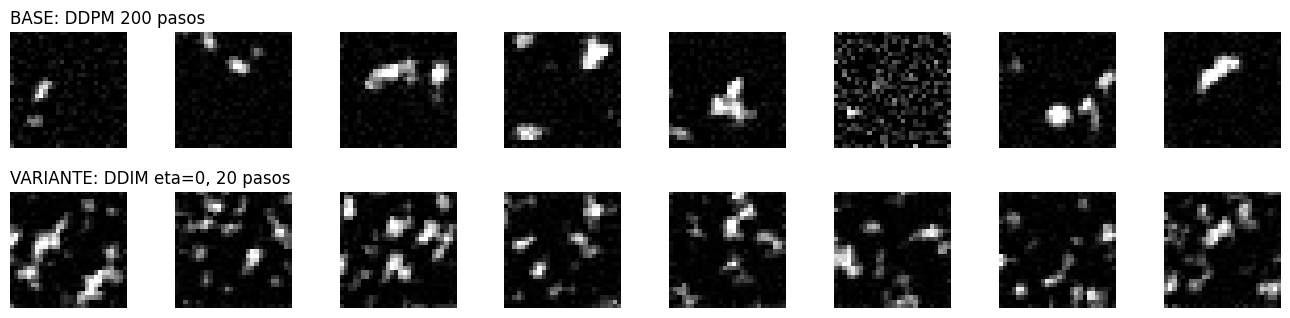

In [17]:
# AÑADIDO por el estudiante: comparación visual lado a lado (base vs variante)
fig, axes = plt.subplots(2, 8, figsize=(13, 3.4))
for i in range(8):
    axes[0, i].imshow(samples_base[i, 0].cpu(), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(imgs_ddim[i, 0].cpu(), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("BASE: DDPM %d pasos" % T, loc="left")
axes[1, 0].set_title("VARIANTE: DDIM eta=0, %d pasos" % NUM_STEPS_B, loc="left")
plt.tight_layout(); plt.show()


## 13. Preguntas avanzadas

### 13.1 Preguntas obligatorias del Proyecto 5

**1. ¿Por qué el proceso de difusión hacia adelante es markoviano y cómo se relaciona con la reversibilidad?**

Es markoviano porque cada $x_t$ depende solo de $x_{t-1}$: en cada paso se agrega un poco de ruido gaussiano independiente del pasado. Eso importa para revertir porque cada paso individual destruye *poca* información: la posterior de un solo paso, $q(x_{t-1}\mid x_t, x_0)$, también es gaussiana y de varianza pequeña, así que una red puede aprenderla. Revertir de golpe ruido→imagen sería aprender una distribución multimodal intratable; revertir 200 micro-pasos gaussianos sí es tratable. Además, la estructura gaussiana-markoviana es la que da la forma cerrada de `q_sample` (vía `alpha_bars`), que permite entrenar saltando directo de $x_0$ a $x_t$ sin iterar.

**2. ¿Qué representa exactamente el modelo de denoising: la imagen limpia, el ruido agregado o el score?**

Mi `TinyDenoiser` predice el **ruido** $\epsilon$: la pérdida es `F.mse_loss(pred_noise, noise)` en `train_denoiser`. Pero las tres parametrizaciones son algebraicamente equivalentes: de $\epsilon_\theta$ despejo $\hat x_0 = (x_t - \sqrt{1-\bar\alpha_t}\,\epsilon_\theta)/\sqrt{\bar\alpha_t}$ — es la línea `x0_hat` de mi `sample_ddim` — y $\epsilon_\theta$ se relaciona con el score $\nabla_x \log q(x_t)$ por un factor de escala ($\epsilon_\theta \approx -\sqrt{1-\bar\alpha_t}\cdot\text{score}$): predecir ruido es una forma de *score matching*. Se prefiere predecir $\epsilon$ porque su escala es constante (siempre $\mathcal{N}(0,I)$) en todos los niveles $t$, lo que estabiliza el entrenamiento.

**3. ¿Por qué aumentar el número de pasos de difusión mejora la calidad pero también el costo computacional?**

Cada paso de muestreo es una pasada completa por $\epsilon_\theta$, así que el costo es lineal en pasos — mi barrido lo confirma: 0.393 s con 200 pasos y 0.029 s con 20 (≈13×). La calidad mejora con pasos finos porque cada actualización corrige poco ruido y el error de discretización de la trayectoria reverse es pequeño; con saltos grandes, la estimación $\hat x_0$ hecha con mucho ruido es mala y el error se acumula — se ve en mis muestras con 20 y 10 pasos (la confianza del clasificador cae y la entropía sube).

**4. ¿Qué diferencia hay entre muestreo con DDPM y muestreo con DDIM?**

DDPM es el reverse **estocástico markoviano**: reinyecta ruido $z$ con varianza derivada de $\beta_t$ en cada paso y recorre todos los $T$ pasos; cada corrida da muestras distintas. DDIM define un proceso **no markoviano con las mismas marginales** $q(x_t\mid x_0)$ — por eso reutiliza el mismo denoiser sin reentrenar — que (a) permite recorrer una subsecuencia respaciada de tiempos y (b) con $\eta=0$ elimina el ruido intra-cadena: la generación se vuelve una **función determinista de $x_T$**. En mi notebook ambos son la misma función `sample_ddim`: `eta=1` ≈ DDPM y `eta=0` = DDIM; lo demuestro empíricamente con la prueba de determinismo condicional a $x_T$ (misma $x_T$ con RNG libre: DDIM da diferencia exactamente 0 y DDPM diverge).

**5. ¿Cómo se relaciona la varianza del ruido en cada paso con la programación de ruido (noise schedule)?**

El schedule **es** la secuencia $\beta_t$ — en mi código, `linear_beta_schedule`: lineal de 1e-4 a 0.02. $\beta_t$ es la varianza del ruido agregado en el paso $t$ del forward, y determina en cadena $\alpha_t = 1-\beta_t$ y $\bar\alpha_t = \prod_{s\le t}\alpha_s$, que gobierna cuánta señal sobrevive hasta $t$. En el reverse, la varianza reinyectada también sale del schedule: $\sqrt{\beta_t}$ en la línea base DDPM y $\sigma(\eta)$ en DDIM. Un schedule mal diseñado (que destruya la señal demasiado rápido) impide que la red aprenda los pasos intermedios; por eso existen alternativas como el schedule coseno.

### 13.2 Preguntas transversales (selección)

**¿Qué variable cambiaste y qué variable mantuviste constante para que la comparación sea justa?**

Cambié solo dos: `num_steps` (latencia) y `eta` (determinismo/diversidad). Mantuve constantes: el denoiser (entrenado una sola vez), el schedule $\beta$, la semilla 42, `N_SAMPLES=16` y el pipeline de métricas. Nunca toqué pesos entre configuraciones: comparo *muestreadores*, no modelos.

**¿Qué evidencia muestra que tu cambio no fue cosmético?**

Tres evidencias medibles: el tiempo de generación cae más de 10× (0.393 → 0.029 s), la reproducibilidad cambia de estocástica a determinista bit a bit dado $x_T$, y las métricas de calidad se mueven (nitidez de 0.1005 a 0.1584 a 20 pasos). Un cambio cosmético no movería ninguna de las tres.

**¿Qué resultado podría parecer bueno, pero ser técnicamente engañoso?**

La nitidez 0.5694 de DDPM (`eta=1`) con 200 pasos — más de 4× la de imágenes reales (0.1307). No es mejor calidad: mi métrica de nitidez es gradiente espacial medio y el **ruido de alta frecuencia también genera gradientes enormes**; ese valor delata ruido residual, no bordes limpios. Por eso nunca uso la nitidez sola, sino triangulada con la confianza/entropía del clasificador.

**¿Qué parte de tu código controla la reproducibilidad, la latencia, la diversidad y la calidad visual?**

Reproducibilidad: `set_seed` (siembra `random`, NumPy y PyTorch) más `eta=0`. Latencia: `num_steps` — número de pasadas por la red. Diversidad: `eta` y el latente inicial $x_T$. Calidad visual: la combinación de `num_steps`, el `clamp` de `x0_hat` y, aguas arriba, cuánto entrenó el denoiser.

**¿Qué simplificación hiciste por limitaciones de cómputo y qué harías distinto con más recursos?**

Simplifiqué: `TinyDenoiser` de 3 convoluciones en vez de un UNet con atención y *skip connections*, 300 pasos de entrenamiento, $T=200$ en vez de 1000, 16 muestras por configuración y proxies baratos (nitidez + clasificador) en vez de FID. Con más cómputo: UNet real, miles de muestras y FID verdadero (distancia entre estadísticos de *features* Inception de la distribución generada y la real), más un barrido fino de `eta`. Las conclusiones sobre linealidad del costo y determinismo de DDIM no cambiarían; los valores absolutos de calidad sí mejorarían.

**¿Qué componente de tu notebook sería más difícil de detectar si estuviera mal implementado?**

La fórmula de `sigma` en `sample_ddim`: un factor mal puesto no produce error ni cambia formas de tensores — seguiría generando imágenes "razonables" pero con la varianza incorrecta, sesgando la diversidad. Lo detecto con la prueba de determinismo (`sigma` debe ser exactamente 0 con `eta=0`) y comparando estadísticos de muchas muestras contra el DDPM completo.

## 14. Análisis de errores y limitaciones

- **Pocos pasos:** con `num_steps=20` el muestreo deja **ruido residual** y dígitos menos coherentes; es el
  modo de falla esperado al recortar demasiado la trayectoria de *denoising*.
- **Proxy de calidad, no verdad absoluta:** la nitidez premia bordes (un patrón ruidoso puede tener nitidez
  alta sin ser un dígito), por eso la combinamos con el clasificador. Aun así, **no es FID**: no mide
  distancia entre distribuciones de características, solo da una señal barata en CPU.
- **Sesgo del evaluador:** el clasificador se entrenó pocos pasos sobre MNIST; puede sobre/infra-estimar la
  confianza y comparte el sesgo de dominio (solo dígitos MNIST).
- **Modelo de juguete:** `TinyDenoiser` (~pocos miles de parámetros) y 300 pasos de entrenamiento son una
  simplificación por límites de cómputo; un UNet más profundo y más entrenamiento darían muestras más
  nítidas, pero no cambian las conclusiones sobre el trade-off pasos/tiempo ni sobre determinismo de DDIM.


## 15. Conclusión técnica

Con un **único denoiser**, mostramos que: (1) el **tiempo de generación escala con el número de pasos**,
(2) reducir pasos degrada la calidad de forma gradual hasta volverse evidente con muy pocos pasos, y
(3) el muestreador **DDIM `eta=0`** logra generación **determinista y reproducible** con pocos pasos —útil
para baja latencia y experimentos controlados— a cambio de **menor diversidad** frente al **DDPM
estocástico**. La comparación es **justa** porque solo cambiamos el muestreo, manteniendo pesos, schedule y
semilla constantes.

## 16. Declaración de autoría y uso de IA

> Declaro que comprendo el código, los resultados y las explicaciones entregadas en esta práctica.
> Si utilicé herramientas de IA, las use como apoyo para redacción, depuración o consulta, pero la
> implementación final, la interpretación técnica y la defensa del trabajo son responsabilidad mia.

**Detalle del uso de IA en esta entrega:**

- Usé IA para revisar la redacción de las secciones teóricas y del README.
- Usé IA para depurar la fórmula del paso DDIM (manejo de `alpha_bar_prev` en el último paso) y verificar
  formas de tensores.
- La línea base proviene de `Semana12/Cuaderno25-CC0C2.ipynb` (marcada como reutilizada). El muestreador
  DDIM, el barrido de pasos, las métricas y las comparaciones son aporte propio, que entiendo y puedo
  defender.


## 17. Qué hice, por qué lo hice y qué significan mis resultados

**Qué hice.** Entrené un denoiser de difusión sobre MNIST y construí un muestreador respaciado
(`sample_ddim`) que generaliza DDPM y DDIM mediante `num_steps` y `eta`.

**Por qué lo hice.** Para aislar el efecto del **muestreo** (no del entrenamiento) sobre el trade-off
calidad–latencia, que es la pregunta central del Proyecto 5. Cambiar `num_steps` toca la **latencia**;
cambiar `eta` toca **determinismo/diversidad**.

**Qué significan los resultados.** El tiempo es casi proporcional a los pasos; DDIM `eta=0` es reproducible
y eficiente con pocos pasos; DDPM aporta diversidad estocástica. Las métricas (tiempo, nitidez, confianza,
entropía) cuantifican que la modificación **no es cosmética**: cambia el comportamiento medible del sistema.


## 18. Puente al curso

Este proyecto conecta con al menos dos temas del curso CC0C2:

- **Modelos de difusión y Stable Diffusion / generación condicionada.** El mismo objetivo de *predecir el
  ruido* y el rol del **scheduler** (DDPM/DDIM, número de pasos, `eta`) son los que operan en Stable
  Diffusion; aquí los vemos en versión mínima y transparente. El paso a *latent diffusion* sería mover este
  proceso al **espacio latente** de un VAE (Cuaderno25).
- **Latencia y throughput (despliegue/MLOps).** El barrido de `num_steps` es exactamente la palanca de
  **latencia de inferencia** en producción: menos pasos = menor costo por imagen. La elección DDPM vs DDIM
  es una decisión de despliegue (reproducibilidad y velocidad vs diversidad), alineada con la discusión de
  *edge vs cloud* y optimización de inferencia del material de la Semana 13 (`Mlops.md`).

Además se relaciona con **espacios latentes** (VAE como compresor previo a la difusión) y con
**Vision Transformers** (un DiT reemplaza el denoiser convolucional por un Transformer sobre patches).
